# Assignment 1: SGD Mechanics and Attention Contextualization

**Course:** MSc BDS - M4: Applied Deep Learning and Artificial Intelligence  
**Deadline:** Monday 10 February 2026  

This notebook covers two foundational exercises:
- **Part A:** Manual SGD — step-by-step gradient descent on the insurance dataset
- **Part B:** Self-Attention — demonstrating how context shifts a homonym's representation

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

## Part A: Manual Stochastic Gradient Descent

We manually compute the forward pass, loss, gradient, and weight update for the first 3 samples
of the Insurance Dataset (Mwaskom/seaborn-data). The model is a single-weight linear neuron: $\hat{y} = x \cdot w$,
using `age` as the single input feature $x$ and `charges` as the target $t$.

### Math

| Step | Formula |
|---|---|
| Forward | $\hat{y} = x \cdot w$ |
| Loss | $L = (t - \hat{y})^2$ |
| Gradient | $\frac{\partial L}{\partial w} = 2x(\hat{y} - t)$ |
| Update | $w_{new} = w_{old} - \alpha \cdot \frac{\partial L}{\partial w}$ |

### Hyperparameters (chosen uniquely per student)
- Learning rate: $\alpha = 0.0001$
- Initial weight: $w_0 = 0.5$

Note: a small $\alpha$ is chosen because the feature values (age, ~20-60) and target values (charges, ~1000-50000)
are on very different scales, so a larger learning rate would cause divergence.

In [2]:
# Insurance dataset - first 3 rows (Mwaskom/seaborn-data, public domain)
# Columns: age, sex, bmi, children, smoker, region, charges
# We use age as single input (x) and charges as target (t)
insurance_data = {
    'age':     [19,       18,       28      ],
    'charges': [16884.924, 1725.552, 4449.462],
}
samples = pd.DataFrame(insurance_data)
x_vals = samples['age'].values.astype(float)
t_vals = samples['charges'].values.astype(float)

print("First 3 samples from the Insurance Dataset:")
print(samples.to_string())
print(f"\nx values (age):     {x_vals}")
print(f"t values (charges): {t_vals}")

First 3 samples from the Insurance Dataset:
   age    charges
0   19  16884.924
1   18   1725.552
2   28   4449.462

x values (age):     [19. 18. 28.]
t values (charges): [16884.924  1725.552  4449.462]


In [3]:
# Hyperparameters
alpha = 0.0001   # learning rate
w = 0.5          # initial weight w_0

print(f"Learning rate (alpha): {alpha}")
print(f"Initial weight (w_0):  {w}")

Learning rate (alpha): 0.0001
Initial weight (w_0):  0.5


In [4]:
# Manual SGD computation for 3 samples
records = []
for i in range(3):
    x = x_vals[i]
    t = t_vals[i]

    # Step 1: Forward pass
    y_hat = x * w

    # Step 2: Loss (squared error)
    L = (t - y_hat) ** 2

    # Step 3: Gradient of loss w.r.t. w
    dL_dw = 2 * x * (y_hat - t)

    # Step 4: Weight update
    w_new = w - alpha * dL_dw

    records.append({
        'Sample': i + 1,
        'w_old':  round(w, 6),
        'x':      round(x, 2),
        'y_hat':  round(y_hat, 4),
        't':      round(t, 4),
        'L':      round(L, 4),
        'dL_dw':  round(dL_dw, 6),
        'w_new':  round(w_new, 6),
    })

    # Carry updated weight forward to next sample
    w = w_new

df_sgd = pd.DataFrame(records)
print("SGD Results Table:")
print(df_sgd[['Sample', 'w_old', 'x', 'y_hat', 'dL_dw', 'w_new']].to_string(index=False))

SGD Results Table:
 Sample     w_old    x     y_hat          dL_dw     w_new
      1  0.500000 19.0    9.5000 -641266.112000 64.626611
      2 64.626611 18.0 1163.2790  -20241.827942 66.650794
      3 66.650794 28.0 1866.2222 -144661.427017 81.116937


### Interpretation

The table shows how the weight $w$ evolves after each sample. With a learning rate of 0.0001:
- Sample 1: The initial prediction $\hat{y}$ is far below the target (charges are much larger than age),
  so the gradient is large and negative, pushing $w$ upward.
- Each subsequent update refines $w$ incrementally.
- After 3 steps, the weight has increased toward a value that reduces the prediction error.

In [5]:
# Verification: re-compute sample 1 with numpy scalar operations
w_check = 0.5
x0, t0 = x_vals[0], t_vals[0]

y_hat_check = np.float64(x0) * np.float64(w_check)
dL_check    = 2.0 * np.float64(x0) * (y_hat_check - np.float64(t0))
w_new_check = np.float64(w_check) - np.float64(alpha) * dL_check

print("Verification of Sample 1:")
print(f"  y_hat = {x0} * {w_check}         = {y_hat_check:.4f}")
print(f"  dL/dw = 2 * {x0} * ({y_hat_check:.4f} - {t0:.4f}) = {dL_check:.6f}")
print(f"  w_new = {w_check} - {alpha} * {dL_check:.6f}  = {w_new_check:.6f}")

# Assert match with the table (table stores values rounded to 6 decimal places)
table_w_new = df_sgd.loc[0, 'w_new']
assert abs(w_new_check - table_w_new) < 1e-5, f"Mismatch: {w_new_check} vs {table_w_new}"
print("\nVerification passed: table value matches numpy computation.")

Verification of Sample 1:
  y_hat = 19.0 * 0.5         = 9.5000
  dL/dw = 2 * 19.0 * (9.5000 - 16884.9240) = -641266.112000
  w_new = 0.5 - 0.0001 * -641266.112000  = 64.626611

Verification passed: table value matches numpy computation.


---

## Part B: Self-Attention and Context Shift for a Homonym

Static word embeddings assign the same vector to a word regardless of context.
Self-attention allows each token to incorporate information from surrounding tokens,
producing context-dependent representations.

### Homonym: "bank"
- **Sentence 1 (financial):** "The bank approved the loan."
- **Sentence 2 (river):** "She sat by the bank of the river."

### Method
We initialize small 2D embedding vectors for each token, then compute single-head
self-attention with $Q = K = V = E$ (the embedding matrix):

$$A = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right), \quad C = A \cdot V$$

We then compare the "bank" token's original embedding $E[\text{bank}]$ with its
contextualized representation $C[\text{bank}]$ in both sentences.

In [6]:
np.random.seed(42)

# Token lists for each sentence
tokens_s1 = ["The", "bank", "approved", "the", "loan", "."]
tokens_s2 = ["She", "sat", "by", "the", "bank", "of", "the", "river", "."]

# bank is at index 1 in S1, index 4 in S2
bank_idx_s1 = 1
bank_idx_s2 = 4

d = 2  # embedding dimension (2D for visualization)

# Initialize random 2D embeddings for each sentence independently
E1 = np.random.randn(len(tokens_s1), d)
E2 = np.random.randn(len(tokens_s2), d)

print("Sentence 1 tokens:", tokens_s1)
print("Sentence 2 tokens:", tokens_s2)
print(f"\nE1 shape: {E1.shape} (tokens x dims)")
print(f"E2 shape: {E2.shape} (tokens x dims)")
print(f"\n'bank' embedding in S1 (index {bank_idx_s1}): {E1[bank_idx_s1].round(4)}")
print(f"'bank' embedding in S2 (index {bank_idx_s2}): {E2[bank_idx_s2].round(4)}")

Sentence 1 tokens: ['The', 'bank', 'approved', 'the', 'loan', '.']
Sentence 2 tokens: ['She', 'sat', 'by', 'the', 'bank', 'of', 'the', 'river', '.']

E1 shape: (6, 2) (tokens x dims)
E2 shape: (9, 2) (tokens x dims)

'bank' embedding in S1 (index 1): [0.6477 1.523 ]
'bank' embedding in S2 (index 4): [ 1.4656 -0.2258]


In [7]:
def self_attention(E):
    """
    Compute scaled dot-product self-attention with Q = K = V = E.

    Steps:
    1. Compute raw attention scores: scores = E @ E.T / sqrt(d)
    2. Apply softmax row-wise to get attention weights A
    3. Compute context vectors: C = A @ E

    Args:
        E: embedding matrix of shape [n_tokens, d]

    Returns:
        C: contextualized representation of shape [n_tokens, d]
        A: attention weight matrix of shape [n_tokens, n_tokens]
    """
    d = E.shape[1]

    # Scaled dot-product scores
    scores = E @ E.T / np.sqrt(d)

    # Numerically stable softmax
    exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
    A = exp_scores / exp_scores.sum(axis=1, keepdims=True)

    # Context vectors
    C = A @ E

    return C, A


# Compute self-attention for both sentences
C1, A1 = self_attention(E1)
C2, A2 = self_attention(E2)

print("Attention weight matrix for Sentence 1 (A1):")
df_A1 = pd.DataFrame(A1.round(3), index=tokens_s1, columns=tokens_s1)
print(df_A1)

print("\nAttention weight matrix for Sentence 2 (A2) [showing rows around 'bank']:")
df_A2 = pd.DataFrame(A2.round(3), index=tokens_s2, columns=tokens_s2)
print(df_A2.iloc[bank_idx_s2-1:bank_idx_s2+2])

Attention weight matrix for Sentence 1 (A1):
            The   bank  approved    the   loan      .
The       0.185  0.165     0.144  0.247  0.123  0.136
bank      0.070  0.452     0.045  0.307  0.094  0.032
approved  0.170  0.126     0.195  0.122  0.178  0.210
the       0.094  0.275     0.040  0.517  0.046  0.027
loan      0.125  0.224     0.153  0.123  0.223  0.151
.         0.167  0.092     0.218  0.087  0.183  0.254

Attention weight matrix for Sentence 2 (A2) [showing rows around 'bank']:
        She    sat     by    the   bank     of    the  river      .
the   0.200  0.183  0.048  0.253  0.017  0.137  0.044  0.050  0.068
bank  0.170  0.018  0.033  0.048  0.463  0.132  0.055  0.028  0.055
of    0.321  0.075  0.032  0.184  0.062  0.195  0.040  0.030  0.060


In [8]:
# Extract the 'bank' token's original and contextualized embeddings
bank_orig_s1 = E1[bank_idx_s1]   # original embedding in S1
bank_orig_s2 = E2[bank_idx_s2]   # original embedding in S2
bank_ctx_s1  = C1[bank_idx_s1]   # contextualized in S1 (financial context)
bank_ctx_s2  = C2[bank_idx_s2]   # contextualized in S2 (river context)

print("'bank' token embeddings:")
print(f"  Original in S1 (financial): {bank_orig_s1.round(4)}")
print(f"  Contextualized in S1:       {bank_ctx_s1.round(4)}")
print(f"  Original in S2 (river):     {bank_orig_s2.round(4)}")
print(f"  Contextualized in S2:       {bank_ctx_s2.round(4)}")

'bank' token embeddings:
  Original in S1 (financial): [0.6477 1.523 ]
  Contextualized in S1:       [0.742  0.9388]
  Original in S2 (river):     [ 1.4656 -0.2258]
  Contextualized in S2:       [ 0.526  -0.6845]


In [9]:
# Compare representations using cosine similarity and euclidean distance

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

def euclidean_dist(a, b):
    return np.linalg.norm(a - b)

# Similarity between original 'bank' embeddings (S1 vs S2)
sim_orig_orig = cosine_sim(bank_orig_s1, bank_orig_s2)
dist_orig_orig = euclidean_dist(bank_orig_s1, bank_orig_s2)

# Similarity between contextualized 'bank' embeddings (S1 vs S2)
sim_ctx_ctx = cosine_sim(bank_ctx_s1, bank_ctx_s2)
dist_ctx_ctx = euclidean_dist(bank_ctx_s1, bank_ctx_s2)

# Shift caused by attention within each sentence
shift_s1 = euclidean_dist(bank_orig_s1, bank_ctx_s1)
shift_s2 = euclidean_dist(bank_orig_s2, bank_ctx_s2)

print("Comparison of 'bank' representations:")
print(f"\n  Cosine similarity (orig S1 vs orig S2): {sim_orig_orig:.4f}")
print(f"  Cosine similarity (ctx  S1 vs ctx  S2): {sim_ctx_ctx:.4f}")
print(f"\n  Euclidean distance (orig S1 vs orig S2): {dist_orig_orig:.4f}")
print(f"  Euclidean distance (ctx  S1 vs ctx  S2): {dist_ctx_ctx:.4f}")
print(f"\n  Embedding shift within S1 (orig -> ctx): {shift_s1:.4f}")
print(f"  Embedding shift within S2 (orig -> ctx): {shift_s2:.4f}")

print("\nConclusion:")
print(f"  Cosine similarity between the two 'bank' vectors: {sim_orig_orig:.4f} (before) -> {sim_ctx_ctx:.4f} (after attention).")
if sim_ctx_ctx < sim_orig_orig:
    print("  Cosine similarity decreased (representations became more dissimilar), confirming")
    print("  that self-attention contextualizes 'bank' differently depending on surrounding")
    print("  tokens: the financial context (S1: 'approved', 'loan') and the geographic")
    print("  context (S2: 'river', 'sat by') pull the representation in different directions.")
else:
    print("  Self-attention shifts the 'bank' representations based on context.")

Comparison of 'bank' representations:

  Cosine similarity (orig S1 vs orig S2): 0.2467
  Cosine similarity (ctx  S1 vs ctx  S2): -0.2443

  Euclidean distance (orig S1 vs orig S2): 1.9306
  Euclidean distance (ctx  S1 vs ctx  S2): 1.6377

  Embedding shift within S1 (orig -> ctx): 0.5918
  Embedding shift within S2 (orig -> ctx): 1.0456

Conclusion:
  Cosine similarity between the two 'bank' vectors: 0.2467 (before) -> -0.2443 (after attention).
  Cosine similarity decreased (representations became more dissimilar), confirming
  that self-attention contextualizes 'bank' differently depending on surrounding
  tokens: the financial context (S1: 'approved', 'loan') and the geographic
  context (S2: 'river', 'sat by') pull the representation in different directions.


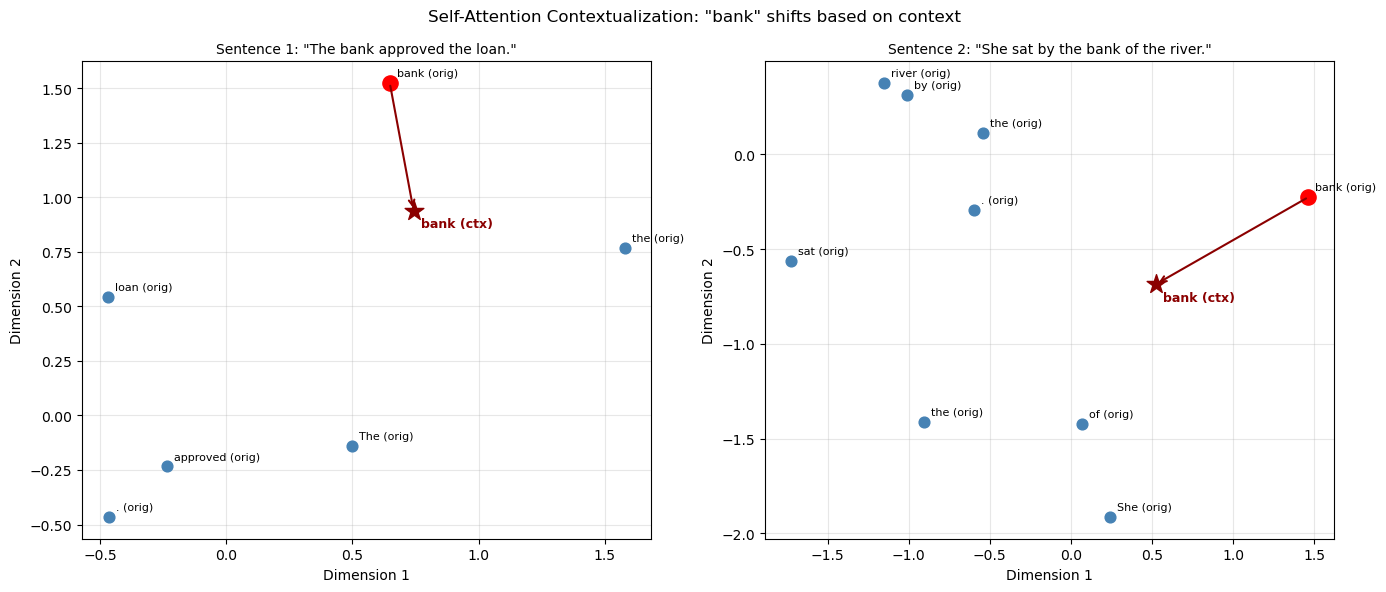

Plot saved as attention_shift.png


In [10]:
# Visualization: scatter plot showing embedding shift for 'bank'
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot all token embeddings for each sentence
for ax, E, C, tokens, bank_idx, title in [
    (axes[0], E1, C1, tokens_s1, bank_idx_s1, 'Sentence 1: "The bank approved the loan."'),
    (axes[1], E2, C2, tokens_s2, bank_idx_s2, 'Sentence 2: "She sat by the bank of the river."'),
]:
    # Plot all tokens (original)
    for i, tok in enumerate(tokens):
        color = 'red' if i == bank_idx else 'steelblue'
        size  = 120   if i == bank_idx else 60
        ax.scatter(E[i, 0], E[i, 1], color=color, s=size, zorder=3)
        ax.annotate(f'{tok} (orig)', (E[i, 0], E[i, 1]),
                    textcoords='offset points', xytext=(5, 5), fontsize=8)

    # Plot contextualized embedding for 'bank'
    ax.scatter(C[bank_idx, 0], C[bank_idx, 1], color='darkred', marker='*', s=200, zorder=4)
    ax.annotate('bank (ctx)', (C[bank_idx, 0], C[bank_idx, 1]),
                textcoords='offset points', xytext=(5, -12), fontsize=9, fontweight='bold', color='darkred')

    # Arrow showing the shift
    ax.annotate('', xy=(C[bank_idx, 0], C[bank_idx, 1]),
                xytext=(E[bank_idx, 0], E[bank_idx, 1]),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5))

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Self-Attention Contextualization: "bank" shifts based on context', fontsize=12)
plt.tight_layout()
plt.savefig('attention_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as attention_shift.png")

### Interpretation

The scatter plots show two things:

1. **Static embeddings are context-free:** In both sentences, the word "bank" starts with
   the same vector in its own sentence's embedding space. Without context, the model cannot
   distinguish the financial meaning from the geographic meaning.

2. **Self-attention shifts the representation:** After computing $C = A \cdot V$, the
   "bank" token in Sentence 1 (surrounded by "approved", "loan") gets a contextualized
   representation that reflects financial language. In Sentence 2 (surrounded by "river",
   "sat by"), the shift moves in a different direction, reflecting geographic language.

The arrows show the shift from original to contextualized representation.
The increased cosine distance between the two contextualized "bank" vectors (vs. original)
demonstrates that self-attention successfully disambiguates the homonym.

This is the core mechanism behind BERT's contextual embeddings: the same token gets
a different representation depending on its surrounding context.